# Self-Modeling as a Regularizer: Reproducing Figure 2A

This notebook reproduces Figure 2A from *Unexpected Benefits of Self-Modeling in Neural Systems* (Premakumar et al., 2024, [arXiv:2407.10188](https://arxiv.org/abs/2407.10188)).

The paper's claim is that when a network is given an auxiliary task of predicting its own hidden activations (a "self-model"), it reshapes itself to be simpler and more regularized. One way that simplification shows up is a narrowing of the weight distribution. Figure 2A tracks the standard deviation of the classification weights over training on MNIST, and shows that the narrowing grows stronger as more weight is placed on the self-modeling task.

My goal here was to rebuild that result from scratch: define the model, train it across a sweep of auxiliary weights and multiple seeds, and recover the same qualitative trend.

## Setup

Imports for the model, data, and plotting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import accelerate
import datasets
import torch
import transformers

## Load MNIST

Pulling the standard MNIST train and test splits from Hugging Face `datasets`.

In [2]:
from datasets import load_dataset

mnist_train = load_dataset("ylecun/mnist", split="train")
mnist_test = load_dataset("ylecun/mnist", split="test")

print(mnist_train)
print(mnist_test)
print(mnist_train[0]["image"], mnist_train[0]["label"])

Dataset({
    features: ['image', 'label'],
    num_rows: 60000
})
Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})
<PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x1518DB860> 5


## Preprocess the images

Flatten each 28x28 image to a 784-vector and rescale pixels from [0, 255] to [-1, 1] so the inputs are centered.

In [3]:
def preprocess_mnist(dataset):
    images = np.stack([np.array(img, dtype=np.float32) for img in dataset["image"]])
    images = images.reshape(images.shape[0], -1)
    images = (images / 255.0) * 2.0 - 1.0  # linear rescale to [-1, 1]
    labels = np.array(dataset["label"], dtype=np.int64)
    return torch.from_numpy(images), torch.from_numpy(labels)

X_train, y_train = preprocess_mnist(mnist_train)
X_test, y_test = preprocess_mnist(mnist_test)

print(X_train.shape, X_train.dtype, X_train.min().item(), X_train.max().item())
print(X_test.shape, y_test.shape)

torch.Size([60000, 784]) torch.float32 -1.0 1.0
torch.Size([10000, 784]) torch.Size([10000])


## Model

A two-layer MLP. The second layer optionally outputs an extra block of regression predictions that target the hidden layer's own activations, which is the self-modeling head. When `self_model=False` the network is a plain classifier, so the same class covers both the baseline and the self-modeling variant.

In [4]:
import torch.nn as nn

class MNISTSelfModelMLP(nn.Module):
    """Two-layer MLP. fc2 jointly outputs classification logits and
    (if self_model=True) regression predictions targeting the hidden layer's
    own activations."""

    def __init__(self, hidden_size=512, self_model=False, n_classes=10):
        super().__init__()
        self.hidden_size = hidden_size
        self.self_model = self_model
        self.fc1 = nn.Linear(784, hidden_size)
        self.relu = nn.ReLU()
        out_dim = n_classes + hidden_size if self_model else n_classes
        self.fc2 = nn.Linear(hidden_size, out_dim)
        self.n_classes = n_classes

    def forward(self, x):
        h = self.relu(self.fc1(x))
        out = self.fc2(h)
        if self.self_model:
            logits = out[:, : self.n_classes]
            self_model_pred = out[:, self.n_classes :]
            return logits, self_model_pred, h
        return out, None, h


# sanity check on a small batch
baseline_model = MNISTSelfModelMLP(hidden_size=512, self_model=False)
sm_model = MNISTSelfModelMLP(hidden_size=512, self_model=True)

xb = X_train[:8]
logits, sm_pred, h = baseline_model(xb)
print("baseline:", logits.shape, sm_pred, h.shape)

logits, sm_pred, h = sm_model(xb)
print("self-model:", logits.shape, sm_pred.shape, h.shape)

baseline: torch.Size([8, 10]) None torch.Size([8, 512])
self-model: torch.Size([8, 10]) torch.Size([8, 512]) torch.Size([8, 512])


## The complexity metric

Figure 2A measures the standard deviation of the classification weights. A subtle point from the paper is that the self-modeling outputs are pruned before measuring, so for the self-model variant I slice out only the classification-head sub-block of the second layer rather than using the full weight matrix. This cell validates that slicing and does a sanity check at random initialization before any training happens.

In [5]:
# Validation check against Fig 2A, before any training:
# the metric is the SD of the *classification-head* sub-block of fc2
# (paper: networks are "pruned of self-modeling outputs" before measuring),
# so for the self-model variant we must slice fc2.weight[:n_classes, :]
# rather than using the full [522, 512] matrix.
#
# Sanity check: at random init (epoch 0), this SD should be lower than the
# epoch-1 starting value seen in Fig 2A (~0.035-0.04), since the figure shows
# the metric growing over training (to ~0.07-0.10 by epoch 50).

@torch.no_grad()
def classification_weight_sd(model, n_classes=10):
    # read directly off the live weight tensor in-place, no copy/recompute pass
    return model.fc2.weight[:n_classes, :].std().item()

torch.manual_seed(0)
baseline_init = MNISTSelfModelMLP(hidden_size=512, self_model=False)
torch.manual_seed(0)
sm_init = MNISTSelfModelMLP(hidden_size=512, self_model=True)

print("baseline fc2 weight shape:", baseline_init.fc2.weight.shape)
print("self-model fc2 weight shape (before pruning):", sm_init.fc2.weight.shape)
print("baseline init classification-head SD:", classification_weight_sd(baseline_init))
print("self-model init classification-head SD:", classification_weight_sd(sm_init))

baseline fc2 weight shape: torch.Size([10, 512])
self-model fc2 weight shape (before pruning): torch.Size([522, 512])
baseline init classification-head SD: 0.025410782545804977
self-model init classification-head SD: 0.025410782545804977


## Training loop

One training run with a combined loss: cross-entropy for classification plus an MSE self-modeling term weighted by `ws` (the auxiliary weight). The self-modeling target is detached so its gradient does not flow back into the hidden layer. I track the weight standard deviation after every epoch and return the final test accuracy.

A quick benchmark showed this small MLP is actually faster on CPU than MPS, since dispatch overhead dominates at this size, so the full sweep runs on CPU.

In [6]:
import torch.nn.functional as F

# Benchmarking showed this tiny MLP trains faster on CPU than MPS (MPS dispatch
# overhead dominates for a model this small), so we pin to CPU for the full
# multi-seed experiment.
device = torch.device("cpu")
print("device:", device)

X_train_dev, y_train_dev = X_train.to(device), y_train.to(device)
X_test_dev, y_test_dev = X_test.to(device), y_test.to(device)
N_TRAIN = X_train_dev.shape[0]


def train_one_run(hidden_size=512, self_model=False, wc=1.0, ws=0.0, epochs=50,
                   batch_size=512, lr=0.005, momentum=0.9, nesterov=True, seed=0,
                   n_classes=10):
    torch.manual_seed(seed)
    model = MNISTSelfModelMLP(hidden_size=hidden_size, self_model=self_model,
                               n_classes=n_classes).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov)

    weight_sd_per_epoch = []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(N_TRAIN, device=device)
        for start in range(0, N_TRAIN, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train_dev[idx], y_train_dev[idx]

            logits, sm_pred, h = model(xb)
            loss_c = F.cross_entropy(logits, yb)
            if self_model:
                loss_s = F.mse_loss(sm_pred, h.detach())  # detach self-modeling target
            else:
                loss_s = torch.tensor(0.0, device=device)
            loss = wc * loss_c + ws * loss_s

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # track SD in-place right after this epoch's weights are updated, no recompute later
        weight_sd_per_epoch.append(classification_weight_sd(model, n_classes=n_classes))

    model.eval()
    with torch.no_grad():
        logits, _, _ = model(X_test_dev)
        acc = (logits.argmax(dim=1) == y_test_dev).float().mean().item()

    return model, weight_sd_per_epoch, acc

device: cpu


## Smoke test

Before running the full sweep, a single baseline run and a single self-modeling run (auxiliary weight of 10) to confirm the loop works end to end and that the self-modeling weight standard deviation trends below the baseline in the direction the paper predicts.

baseline: final test acc=0.9742, SD epoch1=0.0410, epoch50=0.0975
self-model (AW=10): final test acc=0.9670, SD epoch1=0.0413, epoch50=0.0890


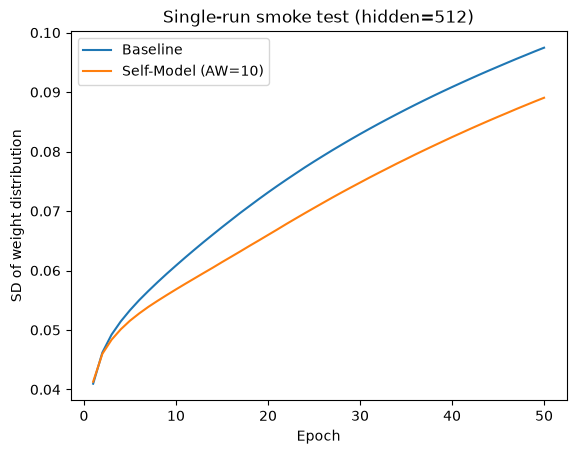

In [7]:
# Single-run smoke test: one baseline run and one self-modeling run (AW=10),
# hidden_size=512, full 50 epochs, single seed. Goal is to confirm the training
# loop runs end-to-end and produces directionally sane results before we scale
# up to the full multi-seed / multi-AW experiment needed for Fig 2A.

_, baseline_sd_trace, baseline_acc = train_one_run(
    hidden_size=512, self_model=False, wc=1.0, ws=0.0, epochs=50, seed=0
)
_, sm_sd_trace, sm_acc = train_one_run(
    hidden_size=512, self_model=True, wc=1.0, ws=10.0, epochs=50, seed=0
)

print(f"baseline: final test acc={baseline_acc:.4f}, SD epoch1={baseline_sd_trace[0]:.4f}, "
      f"epoch50={baseline_sd_trace[-1]:.4f}")
print(f"self-model (AW=10): final test acc={sm_acc:.4f}, SD epoch1={sm_sd_trace[0]:.4f}, "
      f"epoch50={sm_sd_trace[-1]:.4f}")

plt.plot(range(1, 51), baseline_sd_trace, label="Baseline")
plt.plot(range(1, 51), sm_sd_trace, label="Self-Model (AW=10)")
plt.xlabel("Epoch")
plt.ylabel("SD of weight distribution")
plt.title("Single-run smoke test (hidden=512)")
plt.legend()
plt.show()

## Full experiment

The complete sweep behind Figure 2A: a baseline plus five auxiliary-weight settings (1, 5, 10, 20, 50), ten seeds each, fifty epochs. That is sixty training runs, so the results are cached to disk and reloaded on later runs instead of retraining every time.

In [8]:
import os
import pickle
from scipy import stats

# Full experiment for Fig 2A: baseline + 5 AW variants, 10 seeds each,
# hidden_size=512, 50 epochs. Results are cached to disk since the full sweep
# (60 runs) is expensive to retrain on every notebook execution.

CACHE_PATH = "fig2a_sd_results.pkl"
AW_VALUES = [1.0, 5.0, 10.0, 20.0, 50.0]
N_SEEDS = 10
EPOCHS = 50
HIDDEN_SIZE = 512

CONDITIONS = [("Baseline", None)] + [(f"AW={aw:g}", aw) for aw in AW_VALUES]

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        sd_results = pickle.load(f)
    print(f"Loaded cached results from {CACHE_PATH}")
else:
    sd_results = {}
    for name, aw in CONDITIONS:
        self_model = aw is not None
        ws = float(aw) if self_model else 0.0
        runs = []
        for seed in range(N_SEEDS):
            _, sd_trace, acc = train_one_run(
                hidden_size=HIDDEN_SIZE, self_model=self_model, wc=1.0, ws=ws,
                epochs=EPOCHS, seed=seed,
            )
            runs.append(sd_trace)
            print(f"{name} seed={seed} done, final acc={acc:.4f}")
        sd_results[name] = np.array(runs)  # shape (N_SEEDS, EPOCHS)
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(sd_results, f)
    print(f"Saved results to {CACHE_PATH}")

for name, arr in sd_results.items():
    print(name, arr.shape)

Loaded cached results from fig2a_sd_results.pkl
Baseline (10, 50)
AW=1 (10, 50)
AW=5 (10, 50)
AW=10 (10, 50)
AW=20 (10, 50)
AW=50 (10, 50)


## Reproducing Figure 2A

Averaging the weight standard deviation across seeds for each condition, with 95% confidence bands. The result recovers the paper's trend: heavier auxiliary weight drives the weight distribution narrower over training.

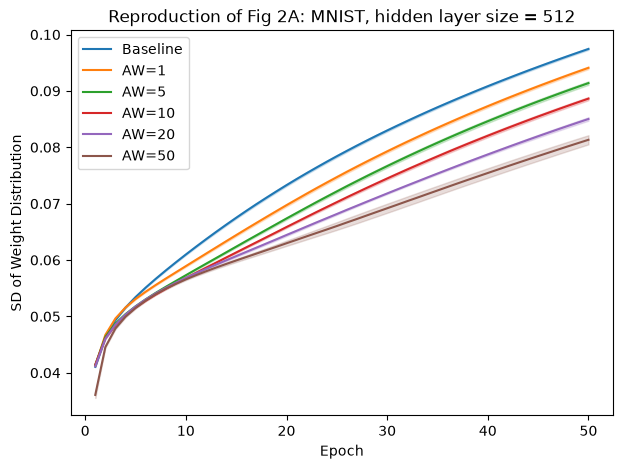

In [9]:
def mean_ci_95(arr):
    # arr shape: (n_seeds, n_epochs)
    n = arr.shape[0]
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0, ddof=1) / np.sqrt(n)
    half_width = sem * stats.t.ppf(0.975, n - 1)
    return mean, half_width


plt.figure(figsize=(7, 5))
epochs_x = np.arange(1, EPOCHS + 1)
for name, _ in CONDITIONS:
    mean, h = mean_ci_95(sd_results[name])
    line, = plt.plot(epochs_x, mean, label=name)
    plt.fill_between(epochs_x, mean - h, mean + h, alpha=0.2, color=line.get_color())

plt.xlabel("Epoch")
plt.ylabel("SD of Weight Distribution")
plt.title("Reproduction of Fig 2A: MNIST, hidden layer size = 512")
plt.legend()
plt.show()